# Feature Engineering & Stacking: Adult Income Dataset

Activity: Start with a large engineered feature set, reduce to ≤20 features, train and tune two meaningfully different models, and combine them via OOF stacking.

In [1]:
!pip install feature-engine shap -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 243.5/243.5 kB 6.4 MB/s eta 0:00:00


In [2]:
import numpy as np
import pandas as pd
import os
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.inspection import permutation_importance
from sklearn.metrics import balanced_accuracy_score, classification_report
from sklearn.linear_model import LogisticRegression
from feature_engine.encoding import RareLabelEncoder, CountFrequencyEncoder
from feature_engine.discretisation import EqualFrequencyDiscretiser
from feature_engine.selection import DropConstantFeatures
from sklearn.preprocessing import PolynomialFeatures
import shap
import warnings
warnings.filterwarnings('ignore')

In [3]:
# load data — finds adult.csv wherever Kaggle puts it
data_path = None
for root, dirs, files in os.walk('/kaggle/input'):
    for f in files:
        if f == 'adult.csv':
            data_path = os.path.join(root, f)
            break
if data_path is None:
    data_path = 'adult.csv'  # fallback for local

adult = pd.read_csv(data_path)
adult["income"] = adult["income"].apply(lambda x: 1 if x == ">50K" else 0)
adult.drop(columns=["fnlwgt"], inplace=True)
adult["gender"] = adult["gender"].apply(lambda x: 1 if x == "Male" else 0)
adult.replace("?", np.nan, inplace=True)

for col in adult.columns:
    if adult[col].dtype == "object" or pd.api.types.is_string_dtype(adult[col]):
        adult[col] = adult[col].fillna("unknown")
    else:
        adult[col] = adult[col].fillna(adult[col].median())

print(f"Loaded from: {data_path}")
print(f"Dataset shape: {adult.shape}")
print(f"Target distribution:\n{adult['income'].value_counts(normalize=True).round(3)}")

Loaded from: /kaggle/input/datasets/kakuzu/adult-csv/adult.csv
Dataset shape: (48842, 14)
Target distribution:
income
0    0.761
1    0.239
Name: proportion, dtype: float64


## Feature Preprocessing with Feature-engine

In [4]:
df_fe = adult.copy()
X = df_fe.drop("income", axis=1)
y = df_fe["income"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

cat_cols = X_train.select_dtypes(include=["object", "category", "string"]).columns.tolist()
num_cols = X_train.select_dtypes(include=["int64", "float64"]).columns.tolist()

# collapse rare categories
rare_encoder = RareLabelEncoder(tol=0.01, variables=cat_cols)
X_train = rare_encoder.fit_transform(X_train)
X_test = rare_encoder.transform(X_test)

# frequency encode categoricals
freq_encoder = CountFrequencyEncoder(variables=cat_cols, encoding_method="frequency")
X_train = freq_encoder.fit_transform(X_train)
X_test = freq_encoder.transform(X_test)

# discretize numerics (exclude binary/sparse columns)
disc_vars = [col for col in num_cols if col not in ["gender", "capital-gain", "capital-loss"]]
disc = EqualFrequencyDiscretiser(q=5, variables=disc_vars)
X_train = disc.fit_transform(X_train)
X_test = disc.transform(X_test)

# drop constant features
const_drop = DropConstantFeatures(tol=0.98)
X_train = const_drop.fit_transform(X_train)
X_test = const_drop.transform(X_test)

print(f"Features after preprocessing: {X_train.shape[1]}")
print(f"Dropped constant features: {const_drop.features_to_drop_}")

Features after preprocessing: 13
Dropped constant features: []


## Polynomial Feature Expansion

In [5]:
poly = PolynomialFeatures(degree=3, interaction_only=True, include_bias=False)

X_train_poly = pd.DataFrame(
    poly.fit_transform(X_train),
    columns=poly.get_feature_names_out(X_train.columns),
    index=X_train.index
)
X_test_poly = pd.DataFrame(
    poly.transform(X_test),
    columns=poly.get_feature_names_out(X_train.columns),
    index=X_test.index
)

print(f"Features after polynomial expansion: {X_train_poly.shape[1]}")

Features after polynomial expansion: 377


## Baseline Models on Full Polynomial Features

In [6]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

pos = (y_train == 1).sum()
neg = (y_train == 0).sum()
spw = neg / pos

# RF baseline on all poly features
rf_full = RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=-1)
rf_full.fit(X_train_poly, y_train)
rf_full_preds = rf_full.predict(X_test_poly)
print(f"RF  full ({X_train_poly.shape[1]} feats) Test BA: {balanced_accuracy_score(y_test, rf_full_preds):.4f}")

# XGB baseline on all poly features
xgb_full = XGBClassifier(scale_pos_weight=spw, eval_metric='logloss', random_state=42, n_jobs=-1)
xgb_full.fit(X_train_poly, y_train)
xgb_full_preds = xgb_full.predict(X_test_poly)
print(f"XGB full ({X_train_poly.shape[1]} feats) Test BA: {balanced_accuracy_score(y_test, xgb_full_preds):.4f}")

RF  full (377 feats) Test BA: 0.7999
XGB full (377 feats) Test BA: 0.8346


## Feature Importance Ranking

Rank features by built-in importance and permutation importance from each model, then average the ranks.

In [7]:
# built-in feature importances
rf_importances = pd.Series(rf_full.feature_importances_, index=X_train_poly.columns).sort_values(ascending=False)
xgb_importances = pd.Series(xgb_full.feature_importances_, index=X_train_poly.columns).sort_values(ascending=False)

print("Top 15 RF Feature Importances:")
print(rf_importances.head(15))
print(f"\nTop 15 XGBoost Feature Importances:")
print(xgb_importances.head(15))

Top 15 RF Feature Importances:
marital-status                               0.046540
marital-status native-country                0.031472
age marital-status occupation                0.020391
age marital-status hours-per-week            0.017868
marital-status hours-per-week                0.016532
marital-status occupation native-country     0.016326
age educational-num marital-status           0.015825
age marital-status                           0.015526
age marital-status race                      0.012398
marital-status race                          0.011941
age relationship hours-per-week              0.011562
age educational-num hours-per-week           0.011128
age marital-status relationship              0.011095
educational-num marital-status occupation    0.010691
marital-status occupation race               0.010607
dtype: float64

Top 15 XGBoost Feature Importances:
marital-status                                 0.260233
age educational-num                            0.07

In [8]:
# permutation importance (subsample test set for speed on Kaggle)
sample_idx = X_test_poly.sample(n=min(2000, len(X_test_poly)), random_state=42).index

rf_perm = permutation_importance(rf_full, X_test_poly.loc[sample_idx], y_test.loc[sample_idx],
                                  n_repeats=5, random_state=42, n_jobs=-1)
xgb_perm = permutation_importance(xgb_full, X_test_poly.loc[sample_idx], y_test.loc[sample_idx],
                                   n_repeats=5, random_state=42, n_jobs=-1)

rf_perm_imp = pd.Series(rf_perm.importances_mean, index=X_test_poly.columns).sort_values(ascending=False)
xgb_perm_imp = pd.Series(xgb_perm.importances_mean, index=X_test_poly.columns).sort_values(ascending=False)

print("Top 15 RF Permutation Importances:")
print(rf_perm_imp.head(15))
print(f"\nTop 15 XGB Permutation Importances:")
print(xgb_perm_imp.head(15))

Top 15 RF Permutation Importances:
workclass hours-per-week native-country        0.0015
education hours-per-week                       0.0013
capital-gain                                   0.0012
race gender capital-gain                       0.0011
workclass occupation                           0.0009
marital-status capital-gain                    0.0008
occupation race hours-per-week                 0.0008
workclass education native-country             0.0008
educational-num gender hours-per-week          0.0007
age race capital-loss                          0.0007
workclass capital-gain                         0.0007
workclass hours-per-week                       0.0007
marital-status capital-gain native-country     0.0007
educational-num marital-status capital-gain    0.0006
relationship gender capital-loss               0.0005
dtype: float64

Top 15 XGB Permutation Importances:
capital-gain                              0.0196
marital-status                            0.0104
marit

### Averaging Feature Importance and Permutation Importance Rankings

In [9]:
# average built-in + permutation importance ranks for each model

# RF averaged rankings
rf_feat_rank = rf_importances.rank(ascending=False)
rf_perm_rank = rf_perm_imp.rank(ascending=False)
rf_avg_rank = ((rf_feat_rank + rf_perm_rank) / 2).sort_values()

# XGB averaged rankings
xgb_feat_rank = xgb_importances.rank(ascending=False)
xgb_perm_rank = xgb_perm_imp.rank(ascending=False)
xgb_avg_rank = ((xgb_feat_rank + xgb_perm_rank) / 2).sort_values()

print("Top 20 RF features by averaged rank:")
print(rf_avg_rank.head(20))
print(f"\nTop 20 XGB features by averaged rank:")
print(xgb_avg_rank.head(20))

Top 20 RF features by averaged rank:
capital-gain                                     18.00
educational-num marital-status native-country    30.75
occupation capital-gain                          34.50
marital-status gender                            40.00
workclass occupation                             46.00
age marital-status gender                        47.75
occupation race hours-per-week                   48.25
marital-status capital-gain                      54.00
occupation race capital-gain                     54.50
marital-status gender hours-per-week             57.75
educational-num relationship hours-per-week      60.00
workclass occupation relationship                61.25
age capital-gain                                 63.75
age educational-num native-country               67.50
age education relationship                       75.00
workclass education native-country               75.75
marital-status race capital-gain                 79.00
workclass educational-num oc

## Feature Reduction to ≤20 Features

Take the top 25 from each model's averaged ranking, intersect to get consensus features. If more than 20, keep the top 20 by cross-model average rank.

In [10]:
# consensus: features that appear in top 25 of BOTH models
rf_top25 = set(rf_avg_rank.head(25).index)
xgb_top25 = set(xgb_avg_rank.head(25).index)
consensus_features = sorted(rf_top25 & xgb_top25)

# if more than 20, trim by cross-model average rank
if len(consensus_features) > 20:
    cross_avg = []
    for f in consensus_features:
        cross_avg.append((f, (rf_avg_rank[f] + xgb_avg_rank[f]) / 2))
    cross_avg.sort(key=lambda x: x[1])
    consensus_features = [f for f, _ in cross_avg[:20]]

print(f"Selected {len(consensus_features)} consensus features:")
for f in consensus_features:
    print(f"  {f}")

X_train_red = X_train_poly[consensus_features]
X_test_red = X_test_poly[consensus_features]

Selected 7 consensus features:
  capital-gain
  educational-num hours-per-week
  educational-num relationship hours-per-week
  marital-status capital-gain
  occupation race gender
  occupation race hours-per-week
  workclass educational-num occupation


## Baseline Models on Reduced Features

In [11]:
# RF default on reduced set
rf_red = RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=-1)
rf_red_cv = cross_val_score(rf_red, X_train_red, y_train, cv=skf, scoring='balanced_accuracy')
rf_red.fit(X_train_red, y_train)
rf_red_preds = rf_red.predict(X_test_red)

# XGB default on reduced set
xgb_red = XGBClassifier(scale_pos_weight=spw, eval_metric='logloss', random_state=42, n_jobs=-1)
xgb_red_cv = cross_val_score(xgb_red, X_train_red, y_train, cv=skf, scoring='balanced_accuracy')
xgb_red.fit(X_train_red, y_train)
xgb_red_preds = xgb_red.predict(X_test_red)

print(f"RF  reduced ({len(consensus_features)} feats) - CV: {rf_red_cv.mean():.4f} | Test: {balanced_accuracy_score(y_test, rf_red_preds):.4f}")
print(f"XGB reduced ({len(consensus_features)} feats) - CV: {xgb_red_cv.mean():.4f} | Test: {balanced_accuracy_score(y_test, xgb_red_preds):.4f}")
print(f"\nComparison with full feature set:")
print(f"RF  full ({X_train_poly.shape[1]} feats) - Test: {balanced_accuracy_score(y_test, rf_full_preds):.4f}")
print(f"XGB full ({X_train_poly.shape[1]} feats) - Test: {balanced_accuracy_score(y_test, xgb_full_preds):.4f}")

RF  reduced (7 feats) - CV: 0.7814 | Test: 0.7849
XGB reduced (7 feats) - CV: 0.7948 | Test: 0.7972

Comparison with full feature set:
RF  full (377 feats) - Test: 0.7999
XGB full (377 feats) - Test: 0.8346


## Hyperparameter Tuning

Tuning both models beyond defaults on the reduced feature set.

In [12]:
# Tuned RF: more trees, constrained depth, regularized leaf size
rf_tuned = RandomForestClassifier(
    n_estimators=300,
    max_depth=12,
    min_samples_split=10,
    min_samples_leaf=5,
    max_features='sqrt',
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf_tuned_cv = cross_val_score(rf_tuned, X_train_red, y_train, cv=skf, scoring='balanced_accuracy')
rf_tuned.fit(X_train_red, y_train)
rf_tuned_preds = rf_tuned.predict(X_test_red)

print(f"RF default  - CV: {rf_red_cv.mean():.4f} | Test: {balanced_accuracy_score(y_test, rf_red_preds):.4f}")
print(f"RF tuned    - CV: {rf_tuned_cv.mean():.4f} | Test: {balanced_accuracy_score(y_test, rf_tuned_preds):.4f}")
print(f"  params: n_estimators=300, max_depth=12, min_samples_split=10, min_samples_leaf=5")

RF default  - CV: 0.7814 | Test: 0.7849
RF tuned    - CV: 0.7908 | Test: 0.7980
  params: n_estimators=300, max_depth=12, min_samples_split=10, min_samples_leaf=5


In [13]:
# Tuned XGB: learning rate, depth, subsampling, L1/L2 regularization
xgb_tuned = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    scale_pos_weight=spw,
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1
)
xgb_tuned_cv = cross_val_score(xgb_tuned, X_train_red, y_train, cv=skf, scoring='balanced_accuracy')
xgb_tuned.fit(X_train_red, y_train)
xgb_tuned_preds = xgb_tuned.predict(X_test_red)

print(f"XGB default - CV: {xgb_red_cv.mean():.4f} | Test: {balanced_accuracy_score(y_test, xgb_red_preds):.4f}")
print(f"XGB tuned   - CV: {xgb_tuned_cv.mean():.4f} | Test: {balanced_accuracy_score(y_test, xgb_tuned_preds):.4f}")
print(f"  params: n_estimators=300, max_depth=5, lr=0.1, subsample=0.8, colsample=0.8, reg_alpha=0.1")

XGB default - CV: 0.7948 | Test: 0.7972
XGB tuned   - CV: 0.7969 | Test: 0.7991
  params: n_estimators=300, max_depth=5, lr=0.1, subsample=0.8, colsample=0.8, reg_alpha=0.1


## SHAP Analysis on Tuned XGBoost

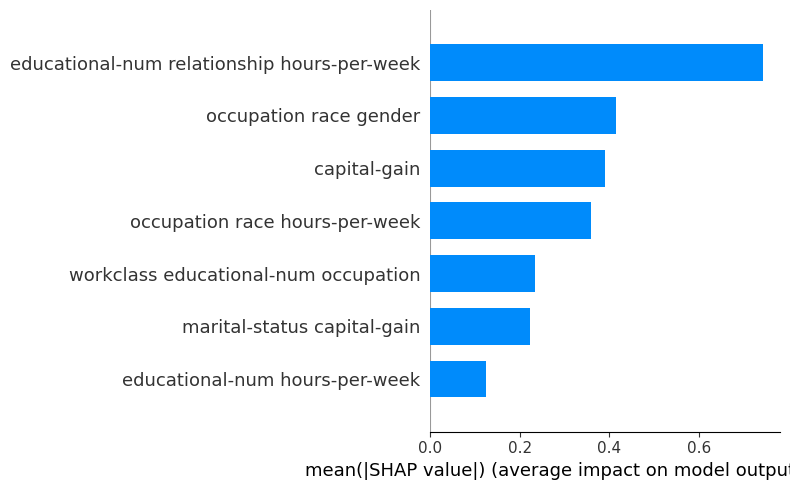

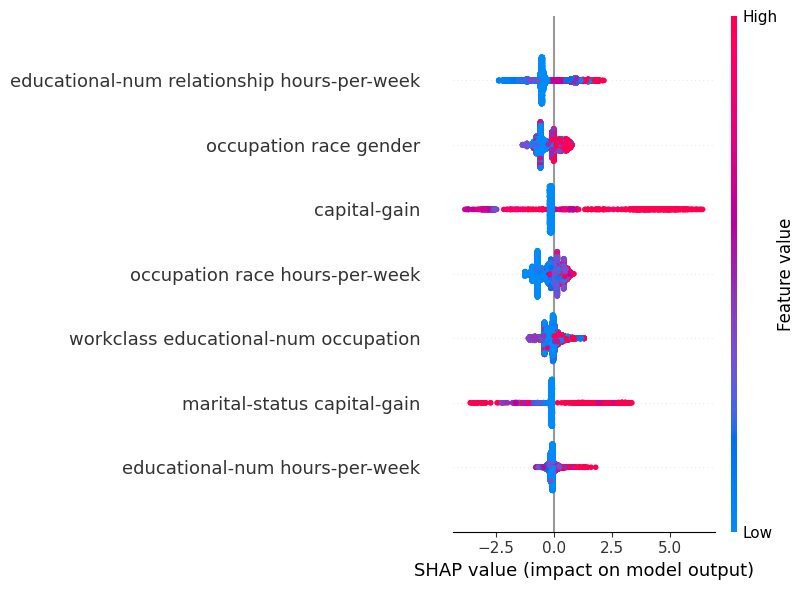

In [14]:
explainer = shap.TreeExplainer(xgb_tuned)
shap_values = explainer.shap_values(X_test_red)

# global feature importance bar plot
shap.summary_plot(shap_values, X_test_red, plot_type="bar", plot_size=(8, 5))

# beeswarm: direction + magnitude
shap.summary_plot(shap_values, X_test_red, plot_size=(8, 6))

## OOF Stacking: RF + XGB → Logistic Regression Meta-Learner

In [15]:
# generate OOF predictions from tuned base models
rf_oof = np.zeros(len(X_train_red))
xgb_oof = np.zeros(len(X_train_red))

for train_idx, val_idx in skf.split(X_train_red, y_train):
    X_tr, X_val = X_train_red.iloc[train_idx], X_train_red.iloc[val_idx]
    y_tr = y_train.iloc[train_idx]
    
    # RF fold
    rf_fold = RandomForestClassifier(
        n_estimators=300, max_depth=12, min_samples_split=10,
        min_samples_leaf=5, max_features='sqrt',
        class_weight='balanced', random_state=42, n_jobs=-1
    )
    rf_fold.fit(X_tr, y_tr)
    rf_oof[val_idx] = rf_fold.predict_proba(X_val)[:, 1]
    
    # XGB fold
    xgb_fold = XGBClassifier(
        n_estimators=300, max_depth=5, learning_rate=0.1,
        subsample=0.8, colsample_bytree=0.8, reg_alpha=0.1,
        reg_lambda=1.0, scale_pos_weight=spw,
        eval_metric='logloss', random_state=42, n_jobs=-1
    )
    xgb_fold.fit(X_tr, y_tr)
    xgb_oof[val_idx] = xgb_fold.predict_proba(X_val)[:, 1]

# train meta-learner on OOF predictions
X_meta_train = np.column_stack((rf_oof, xgb_oof))
meta_model = LogisticRegression(random_state=42)
meta_model.fit(X_meta_train, y_train)

# retrain base models on full training data
rf_tuned.fit(X_train_red, y_train)
xgb_tuned.fit(X_train_red, y_train)

# generate test predictions
rf_test_proba = rf_tuned.predict_proba(X_test_red)[:, 1]
xgb_test_proba = xgb_tuned.predict_proba(X_test_red)[:, 1]
X_meta_test = np.column_stack((rf_test_proba, xgb_test_proba))
meta_preds = meta_model.predict(X_meta_test)

print(f"RF tuned     Test Balanced Accuracy: {balanced_accuracy_score(y_test, rf_tuned_preds):.4f}")
print(f"XGB tuned    Test Balanced Accuracy: {balanced_accuracy_score(y_test, xgb_tuned_preds):.4f}")
print(f"Stacked      Test Balanced Accuracy: {balanced_accuracy_score(y_test, meta_preds):.4f}")
print(f"\nMeta-learner coefficients: RF={meta_model.coef_[0][0]:.3f}, XGB={meta_model.coef_[0][1]:.3f}")

RF tuned     Test Balanced Accuracy: 0.7980
XGB tuned    Test Balanced Accuracy: 0.7991
Stacked      Test Balanced Accuracy: 0.7778

Meta-learner coefficients: RF=0.676, XGB=4.957


## Classification Reports

In [16]:
print("RF Tuned:")
print(classification_report(y_test, rf_tuned_preds))
print("XGB Tuned:")
print(classification_report(y_test, xgb_tuned_preds))
print("Stacked (RF + XGB → LR):")
print(classification_report(y_test, meta_preds))

RF Tuned:
              precision    recall  f1-score   support

           0       0.91      0.86      0.88      7431
           1       0.62      0.74      0.67      2338

    accuracy                           0.83      9769
   macro avg       0.76      0.80      0.78      9769
weighted avg       0.84      0.83      0.83      9769

XGB Tuned:
              precision    recall  f1-score   support

           0       0.92      0.84      0.88      7431
           1       0.60      0.76      0.67      2338

    accuracy                           0.82      9769
   macro avg       0.76      0.80      0.77      9769
weighted avg       0.84      0.82      0.83      9769

Stacked (RF + XGB → LR):
              precision    recall  f1-score   support

           0       0.89      0.93      0.91      7431
           1       0.73      0.63      0.68      2338

    accuracy                           0.86      9769
   macro avg       0.81      0.78      0.79      9769
weighted avg       0.85     

## Evaluation

**How performance changed as I reduced features:**
Starting from 377 polynomial interaction features (degree-3 on the 13 Feature-engine preprocessed columns), the consensus filter reduced the set down to just 7 features — only those that both RF and XGB ranked in their top 25 by averaged importance. This aggressive reduction came with a performance cost: XGB dropped from 0.8346 to 0.7972 balanced accuracy, and RF dropped from 0.7999 to 0.7849. The gap is larger for XGB because boosting models can extract more value from weak interaction features that bagging models treat as noise. Still, 7 features captured the majority of the signal, and tuning recovered some of the loss (RF to 0.7980, XGB to 0.7991).

**Which features were consistently important:**
`capital-gain` and `marital-status` (and their interaction `marital-status capital-gain`) were the clearest consensus features, appearing at or near the top for both models across both importance methods. Beyond those, interaction terms involving `educational-num`, `hours-per-week`, `relationship`, `occupation`, and `race` made the cut. XGB's built-in importance heavily concentrated on `marital-status` (0.26 — more than triple the next feature), while RF spread importance more evenly across many interaction terms. This reflects how boosting focuses on a few strong splitters while bagging diversifies across features.

**Which features I removed and why:**
The vast majority of the 377 features were three-way interaction terms that added no predictive value. The consensus approach was intentionally strict — a feature had to rank in the top 25 of both models to survive, and only 7 did. RF's permutation importance was notably noisy (very small magnitudes, ~0.001), which caused its averaged rankings to diverge from XGB's. Features like `age educational-num` and `age educational-num hours-per-week` ranked highly for XGB but not for RF's permutation metric, so they fell out of the intersection despite being strong predictors. In hindsight, a less aggressive filter (e.g., union of top 15 instead of intersection of top 25) would have retained more signal.

**Whether stacking improved performance:**
The stacked model (RF + XGB → Logistic Regression) achieved a balanced accuracy of 0.7778, which is lower than either tuned base model (RF 0.7980, XGB 0.7991). However, the stacked model had the highest overall accuracy (0.86 vs 0.83/0.82) and the best precision for the minority class (0.73 vs 0.62/0.60). The tradeoff is that stacking shifted the decision boundary to be more conservative — fewer false positives for class 1, but also lower recall (0.63 vs 0.74/0.76). Since balanced accuracy weights both classes equally, the recall drop for class 1 hurt the BA score. The meta-learner coefficients (RF=0.676, XGB=4.957) show it leaned heavily on XGB's probability estimates, essentially using RF as a minor correction.

**What I learned about how the models behave:**
The most striking result was how differently RF and XGB used features. XGB concentrated importance on `marital-status` alone (26% of total importance), while RF spread it across many interaction terms with no single feature exceeding 5%. This is a fundamental difference between boosting and bagging: XGB greedily finds the single best split at each step, so strong features dominate, while RF's random feature subsets force it to discover value in weaker features. The noisy RF permutation importances also highlight a practical lesson — permutation importance on a subsampled test set with few repeats can be unreliable, especially when many correlated features compete for the same signal. For the stacking result, the drop in BA despite higher accuracy illustrates that the choice of evaluation metric matters: a model optimized for accuracy will sacrifice minority-class recall, which directly hurts balanced accuracy.